# Data Analyis

### Data loading

In [32]:
import numpy as np
import pandas as pd
import pyarrow as pa

df = pd.read_csv("./data/raw/customers.csv")
df


,customer_id,full_name,email,phone,city,age,gender,registration_date,customer_segment,is_active
0,CUST0000001,Vikram Singh,vsingh@gmail.com,6882379622,Hyderabad,27.0,Female,2023-05-20,Inactive,0
1,CUST0000002,Kevin Young,kevin.young@gmail.com,8750075334,Delhi,NaN,Male,2023-11-05,Regular,1
2,CUST0000003,David Smith,david2@outlook.com,8766678731,Bangalore,32.0,NaN,2022-10-18,Inactive,0
3,CUST0000004,Fatima Lee,fatima3@yahoo.com,6913090959,Nagpur,23.0,Other,2023-01-29,Regular,1
4,CUST0000005,Fatima Menon,fatimamen@outlook.com,6523478810,Delhi,44.0,Male,2021-05-19,Premium,1
...,...,...,...,...,...,...,...,...,...,...
49995,CUST0049996,Shreya Lee,slee@yahoo.com,9139768484,Mumbai,27.0,Other,2020-12-26,Regular,1
49996,CUST0049997,Mia Sharma,miasha@hotmail.com,8401991336,Pune,NaN,Female,2023-05-13,Premium,1
49997,CUST0049998,Arjun Williams,arjun2@gmail.com,8206085659,Pune,44.0,Female,2021-06-21,Inactive,0
49998,CUST0049999,Kavya Sharma,kavya3@yahoo.com,9395313972,Surat,40.0,Male,2023-02-24,Premium,1


### Understanding data types

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        50000 non-null  str    
 1   full_name          50000 non-null  str    
 2   email              48042 non-null  str    
 3   phone              47053 non-null  str    
 4   city               48970 non-null  str    
 5   age                46590 non-null  float64
 6   gender             48851 non-null  str    
 7   registration_date  50000 non-null  str    
 8   customer_segment   50000 non-null  str    
 9   is_active          50000 non-null  int64  
dtypes: float64(1), int64(1), str(8)
memory usage: 7.6 MB


In [34]:
df_cleaned = df.copy()

### Fixing data inconsistencies

In [35]:
df_cleaned['full_name'] = df_cleaned['full_name'].astype('string')

df_cleaned['city'] = df_cleaned['city'].astype('string')

df_cleaned['gender'] = df_cleaned['gender'].astype('string')

df_cleaned['customer_segment'] = df_cleaned['customer_segment'].astype('category')

df_cleaned['phone'] = pd.to_numeric(df_cleaned['phone'], errors='coerce').astype('Int64')

df_cleaned['age'] = pd.to_numeric(df_cleaned['age'], errors='coerce').astype('Int64')

df_cleaned['registration_date'] = pd.to_datetime(df_cleaned['registration_date'], errors='coerce')

In [36]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        50000 non-null  str           
 1   full_name          50000 non-null  string        
 2   email              48042 non-null  str           
 3   phone              45548 non-null  Int64         
 4   city               48970 non-null  string        
 5   age                46590 non-null  Int64         
 6   gender             48851 non-null  string        
 7   registration_date  50000 non-null  datetime64[us]
 8   customer_segment   50000 non-null  category      
 9   is_active          50000 non-null  int64         
dtypes: Int64(2), category(1), datetime64[us](1), int64(1), str(2), string(3)
memory usage: 6.1 MB


In [37]:
df_cleaned.isna().sum()

customer_id             0
full_name               0
email                1958
phone                4452
city                 1030
age                  3410
gender               1149
registration_date       0
customer_segment        0
is_active               0
dtype: int64

### Fixing the 'gender' column

In [38]:
df_cleaned['gender'] = df_cleaned['gender'].str.strip().str.title()

gender_map = {
    'M': 'Male', 'F': 'Female',
    'Male ': 'Male', 'Female ': 'Female',
    'N/A': None, 'Na': None
}

df_cleaned['gender'] = df_cleaned['gender'].replace(gender_map)

df_cleaned['gender'] = df_cleaned['gender'].fillna('Unknown')

df_cleaned['gender'].value_counts()

gender
Male       25399
Female     21023
Other       2429
Unknown     1149
Name: count, dtype: int64[pyarrow]

In [39]:
df_cleaned['gender'].unique()

<ArrowStringArray>
['Female', 'Male', 'Unknown', 'Other']
Length: 4, dtype: string

In [40]:
df_cleaned['gender']

0         Female
1           Male
2        Unknown
3          Other
4           Male
          ...   
49995      Other
49996     Female
49997     Female
49998       Male
49999       Male
Name: gender, Length: 50000, dtype: string

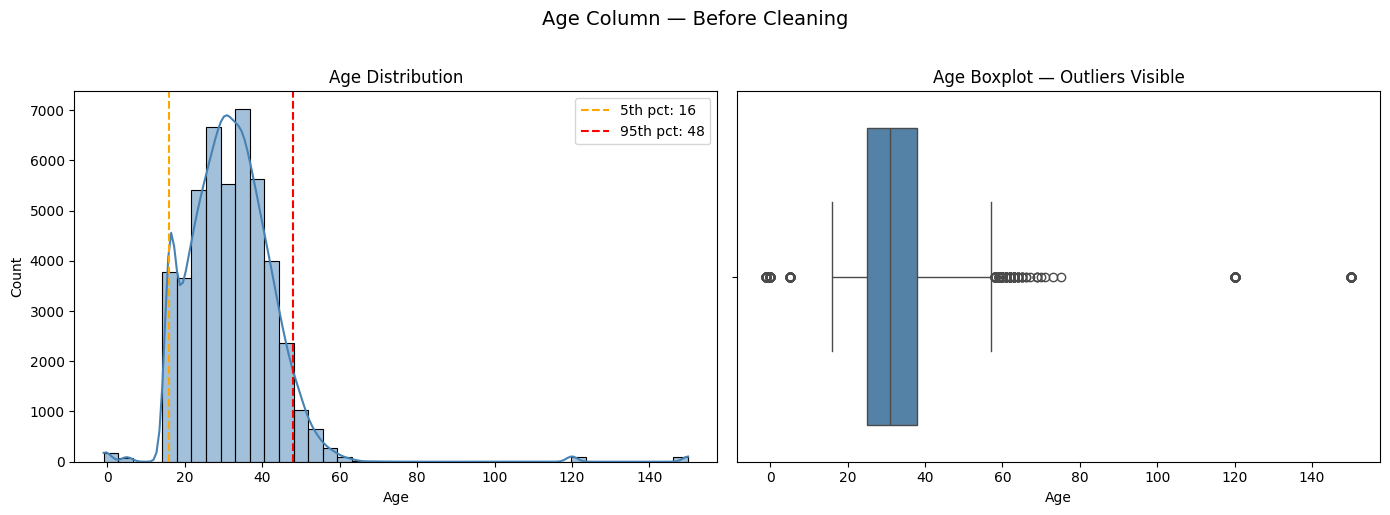

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram — see the distribution shape and outlier spikes
sns.histplot(df['age'].dropna(), bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Add percentile lines so you can visually see where 5th and 95th sit
p05 = df['age'].quantile(0.05)
p95 = df['age'].quantile(0.95)
axes[0].axvline(p05, color='orange', linestyle='--', label=f'5th pct: {p05:.0f}')
axes[0].axvline(p95, color='red',    linestyle='--', label=f'95th pct: {p95:.0f}')
axes[0].legend()

# Plot 2: Boxplot — shows median, IQR, and outlier dots explicitly
sns.boxplot(x=df['age'].dropna(), ax=axes[1], color='steelblue')
axes[1].set_title('Age Boxplot — Outliers Visible')
axes[1].set_xlabel('Age')

plt.suptitle('Age Column — Before Cleaning', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [42]:
df_cleaned['age'] = df_cleaned['age'].where(df_cleaned['age'].between(16, 80), other=pd.NA)

age_median = df_cleaned['age'].median()
print(f"Median age after calculation is {age_median}")

df_cleaned['age'] = df_cleaned['age'].fillna(age_median)

df_cleaned['age']

Median age after calculation is 31.0


0        27
1        31
2        32
3        23
4        44
         ..
49995    27
49996    31
49997    44
49998    40
49999    32
Name: age, Length: 50000, dtype: Int64

In [43]:
df_cleaned.isna().sum()


customer_id             0
full_name               0
email                1958
phone                4452
city                 1030
age                     0
gender                  0
registration_date       0
customer_segment        0
is_active               0
dtype: int64

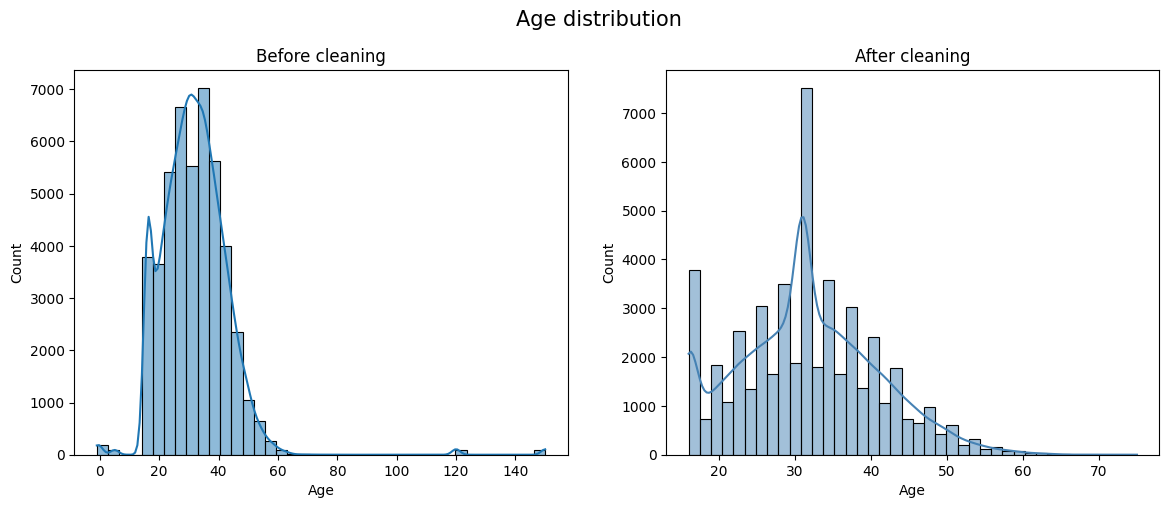

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['age'], bins=40, kde=True, ax=axes[0])
axes[0].set_title('Before cleaning')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.histplot(df_cleaned['age'], bins=40, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('After cleaning')
axes[1].set_xlabel('Age')

plt.suptitle('Age distribution', fontsize=15, y=1)
plt.tight_layout
plt.show()

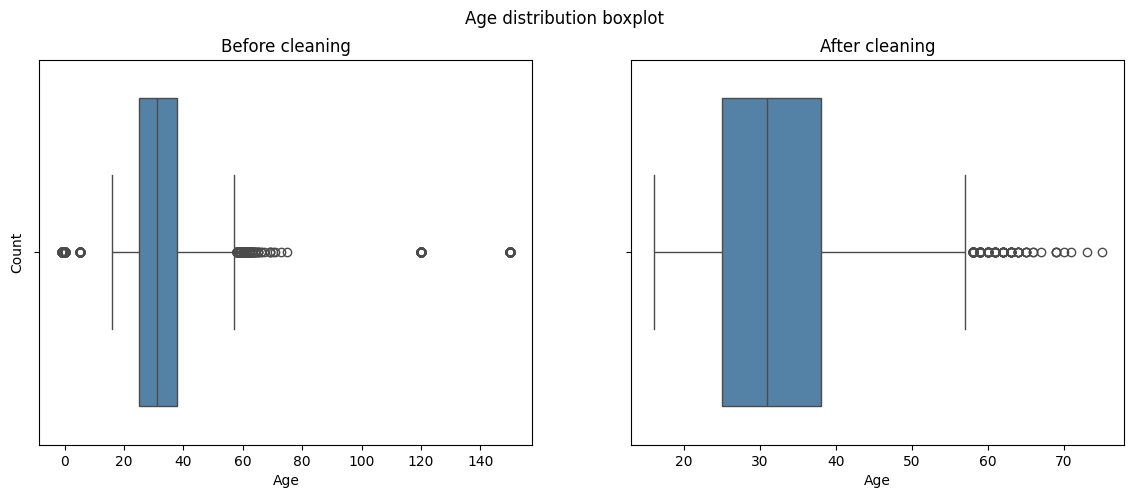

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x=df['age'], ax=axes[0], color='steelblue')
axes[0].set_title('Before cleaning')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

sns.boxplot(x=df_cleaned['age'], ax=axes[1], color='steelblue')
axes[1].set_title('After cleaning')
axes[1].set_xlabel('Age')

plt.suptitle('Age distribution boxplot')
plt.tight_layout
plt.show()

In [46]:
df_cleaned['phone'].describe()

count              45548.0
mean     7790281527.910687
std      1820489173.046117
min                10265.0
25%           6907191562.5
50%           7942463395.0
75%          8974324348.25
max           9999839108.0
Name: phone, dtype: Float64

In [47]:
# A valid Indian mobile number is exactly 10 digits
# and starts with 6, 7, 8, or 9
df_cleaned['phone_available'] = df_cleaned['phone'].where(
    df_cleaned['phone'].astype(str).str.match(r'^[6-9]\d{9}$', na=False),
    other=pd.NA
)

df_cleaned['phone_available'] = df_cleaned['phone_available'].notna().astype(int)

In [48]:
df_cleaned['city_available'] = df_cleaned['city'].notna().astype(int)

In [49]:
valid_email_mask = (
    df_cleaned['email'].notna() &
    df_cleaned['email'].str.contains('@', na=False) &
    ~df_cleaned['email'].str.contains('@@', na=False)
)

df_cleaned['email'] = df_cleaned['email'].where(valid_email_mask, other=pd.NA)
df_cleaned['email_available'] = df_cleaned['email'].notna().astype(int)

In [50]:
df_cleaned

,customer_id,full_name,email,phone,city,age,gender,registration_date,customer_segment,is_active,phone_available,city_available,email_available
0,CUST0000001,Vikram Singh,vsingh@gmail.com,6882379622,Hyderabad,27,Female,2023-05-20,Inactive,0,1,1,1
1,CUST0000002,Kevin Young,kevin.young@gmail.com,8750075334,Delhi,31,Male,2023-11-05,Regular,1,1,1,1
2,CUST0000003,David Smith,david2@outlook.com,8766678731,Bangalore,32,Unknown,2022-10-18,Inactive,0,1,1,1
3,CUST0000004,Fatima Lee,fatima3@yahoo.com,6913090959,Nagpur,23,Other,2023-01-29,Regular,1,1,1,1
4,CUST0000005,Fatima Menon,fatimamen@outlook.com,6523478810,Delhi,44,Male,2021-05-19,Premium,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,CUST0049996,Shreya Lee,slee@yahoo.com,9139768484,Mumbai,27,Other,2020-12-26,Regular,1,1,1,1
49996,CUST0049997,Mia Sharma,miasha@hotmail.com,8401991336,Pune,31,Female,2023-05-13,Premium,1,1,1,1
49997,CUST0049998,Arjun Williams,arjun2@gmail.com,8206085659,Pune,44,Female,2021-06-21,Inactive,0,1,1,1
49998,CUST0049999,Kavya Sharma,kavya3@yahoo.com,9395313972,Surat,40,Male,2023-02-24,Premium,1,1,1,1


In [51]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        50000 non-null  str           
 1   full_name          50000 non-null  string        
 2   email              45485 non-null  str           
 3   phone              45548 non-null  Int64         
 4   city               48970 non-null  string        
 5   age                50000 non-null  Int64         
 6   gender             50000 non-null  string        
 7   registration_date  50000 non-null  datetime64[us]
 8   customer_segment   50000 non-null  category      
 9   is_active          50000 non-null  int64         
 10  phone_available    50000 non-null  int64         
 11  city_available     50000 non-null  int64         
 12  email_available    50000 non-null  int64         
dtypes: Int64(2), category(1), datetime64[us](1), int64(4), str(2), string(3)

In [52]:
obj_cols = df_cleaned.select_dtypes(include='object').columns
df_cleaned[obj_cols] = df_cleaned[obj_cols].astype('string')

C:\Users\Arpan\AppData\Local\Temp\ipykernel_19708\2677810286.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df_cleaned.select_dtypes(include='object').columns


In [53]:
df_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        50000 non-null  string        
 1   full_name          50000 non-null  string        
 2   email              45485 non-null  string        
 3   phone              45548 non-null  Int64         
 4   city               48970 non-null  string        
 5   age                50000 non-null  Int64         
 6   gender             50000 non-null  string        
 7   registration_date  50000 non-null  datetime64[us]
 8   customer_segment   50000 non-null  category      
 9   is_active          50000 non-null  int64         
 10  phone_available    50000 non-null  int64         
 11  city_available     50000 non-null  int64         
 12  email_available    50000 non-null  int64         
dtypes: Int64(2), category(1), datetime64[us](1), int64(4), string(5)
memory 

In [54]:
df_cleaned.duplicated(subset='customer_id').sum() 

np.int64(0)

In [55]:
print(pd.__version__)
print(pa.__version__)

3.0.1
23.0.1
